Dataset dimuat: 2274 baris.


Device set to use cuda:0



Memulai proses klasifikasi zero-shot (Inference)...


100%|██████████| 2274/2274 [13:28<00:00,  2.81it/s]



Distribusi Hasil Prediksi:
SKENARIO     | BENAR              | SALAH              | ERROR             
---------------------------------------------------------------------------
1 Aspek      | 1217 (53.52%)      | 1057 (46.48%)      | 0 (0.00%)         
3 Aspek      | 1160 (51.01%)      | 1114 (48.99%)      | 0 (0.00%)         
5 Aspek      | 1154 (50.75%)      | 1120 (49.25%)      | 0 (0.00%)         

Perbandingan Metrik Evaluasi:
SKENARIO             | AKURASI    | PRESISI    | RECALL     | F1-SCORE  
----------------------------------------------------------------------
1 Aspek              | 0.5352     | 0.5241     | 0.7652     | 0.6221    
3 Aspek              | 0.5101     | 0.5112     | 0.4626     | 0.4857    
5 Aspek              | 0.5075     | 0.5089     | 0.4266     | 0.4641    

Menampilkan visualisasi matriks konfusi (Confusion Matrix)...


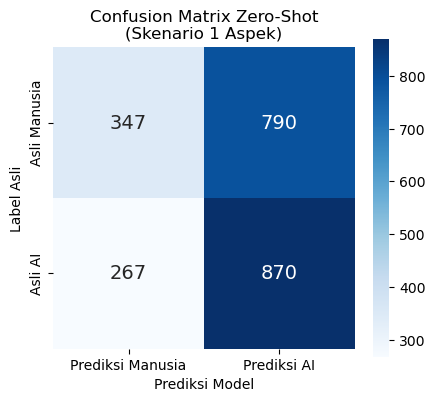

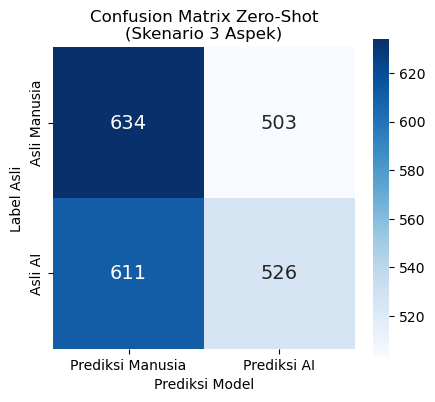

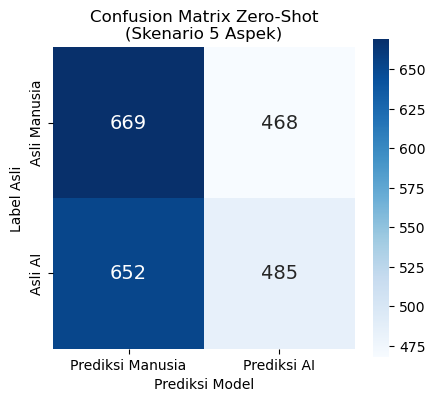


Proses klasifikasi zero-shot selesai.


In [ ]:
import pandas as pd
import numpy as np
from transformers import pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Memuat dataset
df = pd.read_csv('../data/processed/final_dataset_detector_v1_12_fix.csv')
print(f"Dataset dimuat: {len(df)} baris.")

# Inisialisasi model klasifikasi
model_checkpoint = "MoritzLaurer/mDeBERTa-v3-base-mnli-xnli"
classifier = pipeline("zero-shot-classification", model=model_checkpoint, device=0)

# Definisi kandidat label berdasarkan temuan anomali karakteristik
label_sets = [
    {
        "human": "struktur kalimat dalam abstrak ini konsisten, teratur, dan memiliki batasan panjang yang rapi secara natural",
        "ai"   : "struktur kalimat dalam abstrak ini sangat tidak stabil, berfluktuasi secara tidak wajar, dan menumpuk klausa secara berlebihan"
    },
    {
        "human": "data dan angka dalam abstrak ini bersumber dari eksperimen nyata yang dilakukan peneliti secara langsung",
        "ai"   : "data dan angka dalam abstrak ini dihasilkan secara otomatis dan tidak selalu berasal dari eksperimen yang sebenarnya"
    },
    {
        "human": "istilah teknis dalam abstrak ini digunakan dengan tepat karena penulis memiliki pemahaman mendalam tentang bidang penelitiannya",
        "ai"   : "istilah teknis dalam abstrak ini digunakan secara mekanis tanpa pemahaman konteks yang mendalam dari penulisnya"
    },
    {
        "human": "kesimpulan abstrak ini terbatas pada temuan yang benar-benar dibuktikan dalam penelitian tersebut",
        "ai"   : "kesimpulan abstrak ini melampaui temuan yang ada dan mengklaim hasil yang lebih besar dari yang sebenarnya dibuktikan"
    },
    {
        "human": "tanda baca dalam abstrak ini digunakan secara organik dan luwes tanpa pola koma struktural yang kaku",
        "ai"   : "koma dalam abstrak ini digunakan secara sangat kaku dan mekanis untuk mengawali kata transisi serta merangkai klausa panjang"
    },
]

hypothesis_template = "{}."

print("\nMemulai proses klasifikasi zero-shot (Inference)...")
predictions_1 = []
predictions_3 = []
predictions_5 = []

for text in tqdm(df['abstract']):
    votes = []
    try:
        text_input = str(text)

        for ls in label_sets:
            cands = [ls['human'], ls['ai']]
            res   = classifier(
                text_input, cands,
                hypothesis_template=hypothesis_template,
                multi_label=False
            )
            top = res['labels'][0]
            votes.append('human' if top == ls['human'] else 'ai')

        # Skenario voting
        predictions_1.append(votes[0])
        predictions_3.append('human' if votes[:3].count('human') >= 2 else 'ai')
        predictions_5.append('human' if votes.count('human') >= 3 else 'ai')

    except Exception as e:
        predictions_1.append(None)
        predictions_3.append(None)
        predictions_5.append(None)

# Evaluasi hasil prediksi
df['pred_1_aspek'] = predictions_1
df['pred_3_aspek'] = predictions_3
df['pred_5_aspek'] = predictions_5

total_data = len(df)
df_clean = df.dropna(subset=['pred_1_aspek', 'pred_3_aspek', 'pred_5_aspek']).copy()
error_count = total_data - len(df_clean)
error_pct = (error_count / total_data) * 100

y_true = df_clean['label']
configs = [
    ("1 Aspek", df_clean['pred_1_aspek']),
    ("3 Aspek", df_clean['pred_3_aspek']),
    ("5 Aspek", df_clean['pred_5_aspek'])
]

print("\nDistribusi Hasil Prediksi:")
print(f"{'SKENARIO':<12} | {'BENAR':<18} | {'SALAH':<18} | {'ERROR':<18}")
print("-" * 75)

for name, y_pred in configs:
    benar_count = (y_true == y_pred).sum()
    salah_count = (y_true != y_pred).sum()
    
    benar_str = f"{benar_count} ({(benar_count / total_data) * 100:.2f}%)"
    salah_str = f"{salah_count} ({(salah_count / total_data) * 100:.2f}%)"
    error_str = f"{error_count} ({error_pct:.2f}%)"
    
    print(f"{name:<12} | {benar_str:<18} | {salah_str:<18} | {error_str:<18}")

print("\nPerbandingan Metrik Evaluasi:")
print(f"{'SKENARIO':<20} | {'AKURASI':<10} | {'PRESISI':<10} | {'RECALL':<10} | {'F1-SCORE':<10}")
print("-" * 70)

for name, y_pred in configs:
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label='ai', zero_division=0)
    rec = recall_score(y_true, y_pred, pos_label='ai', zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label='ai', zero_division=0)
    print(f"{name:<20} | {acc:<10.4f} | {prec:<10.4f} | {rec:<10.4f} | {f1:<10.4f}")

print("\nMenampilkan visualisasi matriks konfusi (Confusion Matrix)...")
for name, y_pred in configs:
    cm = confusion_matrix(y_true, y_pred, labels=['human', 'ai'])
    plt.figure(figsize=(4.5, 4))  
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        square=True,              
        annot_kws={"size": 14},   
        xticklabels=['Prediksi Manusia', 'Prediksi AI'],
        yticklabels=['Asli Manusia', 'Asli AI']
    )
    
    plt.title(f'Confusion Matrix Zero-Shot\n(Skenario {name})', fontsize=12)
    plt.xlabel('Prediksi Model', fontsize=10)
    plt.ylabel('Label Asli', fontsize=10)
    plt.tight_layout()
    plt.show()

print("\nProses klasifikasi zero-shot selesai.")

In [1]:
import pandas as pd
import numpy as np
from transformers import pipeline
from tqdm import tqdm

print("="*60)
print("  MEMULAI EVALUASI ZERO-SHOT NLI (SCENARIO 1-ASPEK)")
print("="*60)

# 1. Load dataset
df = pd.read_csv('../data/processed/final_dataset_detector_v1_12_fix.csv')
print(f"Dataset berhasil dimuat. Total baris: {len(df)}")

# 2. Inisialisasi Model Pipeline
model_checkpoint = "MoritzLaurer/mDeBERTa-v3-base-mnli-xnli"
print(f"Memuat model zero-shot: {model_checkpoint}...")
classifier = pipeline("zero-shot-classification", model=model_checkpoint, device=0)  

# Hipotesis Scenario 1-Aspect (target: fluktuasi struktur kalimat)
human_hyp = "struktur kalimat dalam abstrak ini konsisten, teratur, dan memiliki batasan panjang yang rapi secara natural"
ai_hyp = "struktur kalimat dalam abstrak ini sangat tidak stabil, berfluktuasi secara tidak wajar, dan menumpuk klausa secara berlebihan"
hypothesis_template = "{}."

# 3. Proses Inferensi
preds = []
print("Menjalankan prediksi zero-shot NLI pada korpus abstrak...")
for text in tqdm(df['abstract'], desc="Progress"):
    res = classifier(str(text), [human_hyp, ai_hyp], hypothesis_template=hypothesis_template, multi_label=False)
    top = res['labels'][0]
    preds.append('human' if top == human_hyp else 'ai')

df['pred_1_aspek'] = preds

# 4. Evaluasi & Tampilan Confusion Matrix Berbentuk Tabel Rapi
# Asumsi label asli: 'human' dan 'ai'
y_true = df['label'].values
y_pred = df['pred_1_aspek'].values

# Hitung Confusion Matrix manual/pandas
cm_data = pd.crosstab(
    pd.Series(y_true, name="Actual Label"), 
    pd.Series(y_pred, name="Predicted Label")
)

print("\n" + "="*50)
print("       CONFUSION MATRIX (CROSS-TABULATION)")
print("="*50)
print(cm_data.to_string())
print("="*50)

# Ringkasan Kuantitatif
total_data = len(df)
# Cek kecocokan dengan skripsi: TP(ai->ai), TN(human->human), FP(human->ai), FN(ai->human)
tn = len(df[(df['label'] == 'human') & (df['pred_1_aspek'] == 'human')])
fp = len(df[(df['label'] == 'human') & (df['pred_1_aspek'] == 'ai')])
fn = len(df[(df['label'] == 'ai') & (df['pred_1_aspek'] == 'human')])
tp = len(df[(df['label'] == 'ai') & (df['pred_1_aspek'] == 'ai')])

acc = (tp + tn) / total_data
prec = tp / (tp + fp) if (tp + fp) > 0 else 0
rec = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0

metrics_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "True Positive (TP)", "True Negative (TN)", "False Positive (FP)", "False Negative (FN)"],
    "Value": [f"{acc:.4f}", f"{prec:.4f}", f"{rec:.4f}", f"{f1:.4f}", tp, tn, fp, fn]
})

print("\n" + "="*50)
print("       RINGKASAN METRIK EVALUASI 1-ASPEK")
print("="*50)
print(metrics_summary.to_string(index=False))
print("="*50)

# 5. Ambil sampel FP dan FN untuk analisis kualitatif
fp_samples = df[(df['label'] == 'human') & (df['pred_1_aspek'] == 'ai')].sample(
    min(20, len(df[(df['label'] == 'human') & (df['pred_1_aspek'] == 'ai')])), random_state=42)
fn_samples = df[(df['label'] == 'ai') & (df['pred_1_aspek'] == 'human')].sample(
    min(20, len(df[(df['label'] == 'ai') & (df['pred_1_aspek'] == 'human')])), random_state=42)

# Tampilkan preview singkat sampel FP
print("\nCONTOH FALSE POSITIVE (Human tapi diprediksi AI)")
print(fp_samples[['source', 'abstract']].head(2).to_string(index=False))
print("="*60)

  MEMULAI EVALUASI ZERO-SHOT NLI (SCENARIO 1-ASPEK)
Dataset berhasil dimuat. Total baris: 2274
Memuat model zero-shot: MoritzLaurer/mDeBERTa-v3-base-mnli-xnli...


Device set to use cuda:0


Menjalankan prediksi zero-shot NLI pada korpus abstrak...


Progress: 100%|██████████| 2274/2274 [02:37<00:00, 14.45it/s]


       CONFUSION MATRIX (CROSS-TABULATION)
Predicted Label   ai  human
Actual Label               
ai               870    267
human            790    347

       RINGKASAN METRIK EVALUASI 1-ASPEK
             Metric  Value
           Accuracy 0.5352
          Precision 0.5241
             Recall 0.7652
           F1-Score 0.6221
 True Positive (TP)    870
 True Negative (TN)    347
False Positive (FP)    790
False Negative (FN)    267

CONTOH FALSE POSITIVE (Human tapi diprediksi AI)
                                                       source                                                                                                                                                                                                                                                                                                                                                                                                                                                                